![image.png](attachment:image.png)

In [ ]:
#Libraries needed: Pandas, Numpy, Matplotlib (Run first)
%pip install pandas
%pip install numpy
%pip install matplotlib

# csv dataset generator

![image.png](attachment:image.png)

In [14]:
import numpy as np
import pandas as pd

np.random.seed(1)

'For generating inspections.csv'

# Random amount of days chosen between 60-120
days = np.random.randint(60, 121)

# Inspection dates, starts at 2026-01-01
date = pd.bdate_range(start='2026-01-01', periods=days)

# Calibration date placed around the middle of the inspection period
calibration_date = date[len(date) // 2]

# Create set dates for inspector certificates (constant pool)
inspector_certificate = pd.to_datetime('2026-01-01') - pd.to_timedelta(np.random.randint(50, 801, size=5), unit="D")

# List to collect rows from your loops
rows = []

# ID loops
for day in range(1, days + 1):
    current_date = date[day - 1]

    # Certification date logic (generated per day)
    inspector_id = np.random.randint(1, 6) # Inspector ID - 1-5 Inspectors
    last_cert_check = inspector_certificate[inspector_id - 1] # assign inspector certificate values to inspector id
    check_cert = (current_date - last_cert_check).days # calculate if its still valid
    is_certified = "Y" if check_cert <= 548 else "N" # Check if inspector last cert date is within 548 days, else expired
    last_cert_date = last_cert_check.strftime("%Y-%m-%d") # turn last cert check to string

    # Convert date as data to make sure it can run
    date_as_data = current_date.strftime("%Y-%m-%d")

    # Rotate through markets 1 to 5 each business day
    market_id = ((day - 1) % 5) + 1

    # If the number of stalls varies between 30 and 50:
    num_stalls = np.random.randint(30, 51)

    for stall_id in range(1, num_stalls + 1):
        for scale_id in range(1, 3):  # Exactly 2 scales (1 and 2)

            # Weight calibration (generated per scale test)
            nominal_weight_g = np.random.choice([100, 250, 500, 1000])

            if current_date < calibration_date:
                error_perc = np.random.uniform(-0.02, 0.02)
            else:
                error_perc = np.random.uniform(-0.005, 0.005)

            reading_g = np.round(nominal_weight_g * (1 + error_perc), 2)

            rows.append({
                "date": date_as_data,
                "market_id": market_id,
                "stall_id": stall_id,
                "scale_id": scale_id,
                "nominal_weight_g": nominal_weight_g,
                "reading_g": reading_g,
                "is_certified": is_certified,
                "last_cert_date": last_cert_date,
                "calibration_date": calibration_date.strftime("%Y-%m-%d"),
                "inspector_id": inspector_id
            })

# Create dataframe
df_inspections = pd.DataFrame(rows)

# 7. Save to CSV
df_inspections.to_csv("inspections.csv", index=False)
print("inspections.csv created")
print(df_inspections.head())

inspections.csv created
         date  market_id  stall_id  scale_id  nominal_weight_g  reading_g  \
0  2026-01-01          1         1         1              1000     993.82   
1  2026-01-01          1         1         2               500     508.71   
2  2026-01-01          1         2         1               100      99.68   
3  2026-01-01          1         2         2               500     500.49   
4  2026-01-01          1         3         1               100     101.51   

  is_certified last_cert_date calibration_date  inspector_id  
0            Y     2025-09-01       2026-03-10             2  
1            Y     2025-09-01       2026-03-10             2  
2            Y     2025-09-01       2026-03-10             2  
3            Y     2025-09-01       2026-03-10             2  
4            Y     2025-09-01       2026-03-10             2  


Prices.csv generator

variables needed: date, market_id, commodity, avg_price_per_kg

In [16]:
import numpy as np
import pandas as pd

np.random.seed(2)

'For generating prices.csv'

#using the code already written in inspecctions.csv
df_inspections = pd.read_csv("inspections.csv")

# Extract the exact dates and count from inspections
inspectiondate = pd.to_datetime(df_inspections['date']).unique()
days = len(inspectiondate) #makes sure it has the exact same days as inspections.csv

# Create a list to collect rows
rows = []


#commodities logic
#commodity list, 8-12 choices
commodity_list = [ 'Rice', 'Chicken', 'Pork', 'Beef',
                  'Bangus', 'Tomatoes', 'Onions', 'Garlic',
                  'Eggplant', 'Cabbage', 'Carrots', 'Potatoes',
                  'Tilapia', 'Ginger']

commodity_amount = np.random.randint(8, 13) #commodity_amount, choose random amount of commodities in the list

#code for choosing which commodities are chosen, replace=False for no duplicates and keep all distinct
commodities_chosen = np.random.choice(commodity_list, size=commodity_amount, replace=False)

#created minmax bound for avg_price_per_kg so each item price is different and actually makes sense for a synthetic

commodity_price_minmax = {
    'Rice': (45.0, 60.0),
    'Chicken': (180.0, 220.0),
    'Pork': (300.0, 380.0),
    'Beef': (350.0, 450.0),
    'Bangus': (160.0, 220.0),
    'Tomatoes': (60.0, 120.0),
    'Onions': (80.0, 150.0),
    'Garlic': (100.0, 180.0),
    'Eggplant': (60.0, 90.0),
    'Cabbage': (80.0, 140.0),
    'Carrots': (90.0, 150.0),
    'Potatoes': (90.0, 140.0),
    'Tilapia': (120.0, 160.0),
    'Ginger': (100.0, 160.0)
}

# generate a price for every date, market, and commodity
for current_date in inspectiondate:
    for market_id in range(1, 6):
        for commodity in commodities_chosen:

            # Get min and max price for the commodity
            minprice = commodity_price_minmax[commodity][0]
            maxprice = commodity_price_minmax[commodity][1]

            # Generate random price within the range
            avg_price_per_kg = np.round(
                np.random.uniform(minprice, maxprice),
                2
            )

            rows.append({
                'date': pd.Timestamp(current_date).strftime('%Y-%m-%d'),
                'market_id': market_id,
                'commodity': commodity,
                'avg_price_per_kg': avg_price_per_kg
            })

# create dataframe from generated rows
df_prices = pd.DataFrame(rows)

# save to CSV
df_prices.to_csv("prices.csv", index=False)

print("Generated prices.csv")
print(df_prices.head())

# show the size of the generated dataset
print("Shape:", df_prices.shape)

Generated prices.csv
         date  market_id commodity  avg_price_per_kg
0  2026-01-01          1  Potatoes            116.46
1  2026-01-01          1    Bangus            168.07
2  2026-01-01          1  Tomatoes             90.81
3  2026-01-01          1      Rice             47.77
4  2026-01-01          1   Cabbage            127.12
Shape: (3880, 4)


Sales_samples.csv generator

variables needed: date, market_id, stall_id, commodity, paid_amount_php, label_weight_kg, actual_weight_kg

In [17]:
import numpy as np
import pandas as pd

np.random.seed(3)

'For generating sales_samples.csv'

df_inspections = pd.read_csv("inspections.csv")
df_prices = pd.read_csv("prices.csv")


# Use the inspection rows as the basis for sales samples
date = df_inspections['date'].values
market_id = df_inspections['market_id'].values
stall_id = df_inspections['stall_id'].values


# Get the commodities available in prices.csv
commodities = df_prices['commodity'].unique()

# Randomly assign a commodity to every sales sample
commodity = np.random.choice(
    commodities,
    size=len(df_inspections)
)


# Label weight
label_weight_kg = np.random.choice(
    [0.5, 1.0, 1.5, 2.0],
    size=len(df_inspections)
)


# Actual weight error
error_perc = np.random.uniform(
    -0.0075,
    0.0025,
    size=len(df_inspections)
)

actual_weight_kg = np.round(
    label_weight_kg * (1 + error_perc),
    3
)


# Create sales dataframe
df_sales = pd.DataFrame({

    'date': date,

    'market_id': market_id,

    'stall_id': stall_id,

    'commodity': commodity,

    'label_weight_kg': label_weight_kg,

    'actual_weight_kg': actual_weight_kg
})


# Get price information from prices.csv
price_lookup = df_prices[
    ['date',
     'market_id',
     'commodity',
     'avg_price_per_kg']
]


# Match each sales sample with its market price
df_sales = df_sales.merge(
    price_lookup,
    on=['date', 'market_id', 'commodity'],
    how='left'
)


# Calculate the amount paid by the customer
paid_amount_php = np.round(
    df_sales['label_weight_kg'] *
    df_sales['avg_price_per_kg'],
    2
)

df_sales['paid_amount_php'] = paid_amount_php


# Keep only the required columns
df_sales = df_sales[
    ['date',
     'market_id',
     'stall_id',
     'commodity',
     'paid_amount_php',
     'label_weight_kg',
     'actual_weight_kg']
]


# Save to CSV
df_sales.to_csv("sales_samples.csv", index=False)

print("sales_samples.csv created")
print(df_sales.head())
print("Shape:", df_sales.shape)


sales_samples.csv created
         date  market_id  stall_id commodity  paid_amount_php  \
0  2026-01-01          1         1  Tomatoes           181.62   
1  2026-01-01          1         1  Potatoes           116.46   
2  2026-01-01          1         2    Bangus           168.07   
3  2026-01-01          1         2      Rice            95.54   
4  2026-01-01          1         3  Potatoes           232.92   

   label_weight_kg  actual_weight_kg  
0              2.0             2.004  
1              1.0             0.995  
2              1.0             0.997  
3              2.0             1.998  
4              2.0             1.985  
Shape: (7752, 7)


# Part A: NumPy Mini-Writeup

The analysis calculated the weighing error in grams and percentage and identified measurements outside the acceptable ±0.5% tolerance. Among the five markets, Market 3 had the highest percentage of inspections outside the tolerance at 41.11%, with 21.36% under-weighing and 19.74% over-weighing. Market 4 had the lowest outside-tolerance percentage at 34.13%. Market 5 had the highest mean error at 0.01%, while Market 1 had the lowest at -0.02%. However, the mean errors of all markets were close to zero, showing that positive and negative errors can offset each other. Therefore, the outside-tolerance rate and under-weighing rate are more useful indicators of consumer risk than mean error alone. Based on these results, Market 3 shows the highest measurement risk and should receive closer monitoring.


![image.png](attachment:image.png)

In [18]:
import numpy as np
import pandas as pd

df = pd.read_csv("inspections.csv")

print(df.head())
print(df.shape)

# Calculate scale error
error_g = df["reading_g"].to_numpy() - df["nominal_weight_g"].to_numpy()
error_pct = (error_g / df["nominal_weight_g"].to_numpy()) * 100

print("Error in grams:")
print(error_g[:5])

print("Error in percent:")
print(error_pct[:5])

# Create masks for weighing errors
under_mask = error_pct < -0.5
over_mask = error_pct > 0.5
outside_mask = under_mask | over_mask

print("Under-weighing:")
print(under_mask[:10])

print("Over-weighing:")
print(over_mask[:10])

print("Outside tolerance:")
print(outside_mask[:10])

# Calculate mean and median error per market
market_ids = df["market_id"].to_numpy()
markets = np.unique(market_ids)

market_mask = market_ids[:, np.newaxis] == markets[np.newaxis, :]
market_errors = np.where(market_mask, error_pct[:, np.newaxis], np.nan)

mean_error = np.nanmean(market_errors, axis=0)
median_error = np.nanmedian(market_errors, axis=0)

print("Markets:", markets)
print("Mean error per market:", mean_error)
print("Median error per market:", median_error)

# Calculate 95% confidence interval
n = np.sum(~np.isnan(market_errors), axis=0)
std_error = np.nanstd(market_errors, axis=0, ddof=1) / np.sqrt(n)

margin_error = 1.96 * std_error

ci_lower = mean_error - margin_error
ci_upper = mean_error + margin_error

print("95% CI lower:", ci_lower)
print("95% CI upper:", ci_upper)

# Calculate fraction of inspections outside tolerance per market
outside_by_market = np.where(market_mask, outside_mask[:, np.newaxis], False)

outside_count = np.sum(outside_by_market, axis=0)
total_count = np.sum(market_mask, axis=0)

outside_fraction = outside_count / total_count
outside_percentage = outside_fraction * 100

print("Inspections outside tolerance:", outside_count)
print("Total inspections per market:", total_count)
print("Fraction outside tolerance:", outside_fraction)
print("Percentage outside tolerance:", outside_percentage)

# Identify markets with the highest and lowest error
highest_outside_market = markets[np.argmax(outside_percentage)]
highest_mean_market = markets[np.argmax(mean_error)]
lowest_mean_market = markets[np.argmin(mean_error)]

print("Market with highest outside-tolerance percentage:",
      highest_outside_market)

print("Market with highest mean error:",
      highest_mean_market)

print("Market with lowest mean error:",
      lowest_mean_market)

# Calculate under-weighing and over-weighing per market
under_by_market = np.where(market_mask, under_mask[:, np.newaxis], False)
over_by_market = np.where(market_mask, over_mask[:, np.newaxis], False)

under_count = np.sum(under_by_market, axis=0)
over_count = np.sum(over_by_market, axis=0)

under_percentage = (under_count / total_count) * 100
over_percentage = (over_count / total_count) * 100

print("Under-weighing count:", under_count)
print("Over-weighing count:", over_count)
print("Under-weighing percentage:", under_percentage)
print("Over-weighing percentage:", over_percentage)

# Create final market summary
summary = pd.DataFrame({
    "Market": markets,
    "Mean Error %": mean_error,
    "Median Error %": median_error,
    "CI Lower": ci_lower,
    "CI Upper": ci_upper,
    "Outside %": outside_percentage,
    "Under %": under_percentage,
    "Over %": over_percentage
})

print("\nFinal Market Summary:")
print(summary.round(2))


         date  market_id  stall_id  scale_id  nominal_weight_g  reading_g  \
0  2026-01-01          1         1         1              1000     993.82   
1  2026-01-01          1         1         2               500     508.71   
2  2026-01-01          1         2         1               100      99.68   
3  2026-01-01          1         2         2               500     500.49   
4  2026-01-01          1         3         1               100     101.51   

  is_certified last_cert_date calibration_date  inspector_id  
0            Y     2025-09-01       2026-03-10             2  
1            Y     2025-09-01       2026-03-10             2  
2            Y     2025-09-01       2026-03-10             2  
3            Y     2025-09-01       2026-03-10             2  
4            Y     2025-09-01       2026-03-10             2  
(7752, 10)
Error in grams:
[-6.18  8.71 -0.32  0.49  1.51]
Error in percent:
[-0.618  1.742 -0.32   0.098  1.51 ]
Under-weighing:
[ True False False False Fals

# Part B: Pandas Mini-Writeup

The inspection, sales, and price datasets were successfully combined to analyze potential consumer losses and weighing patterns by market and commodity. The Market × Commodity results show that expected losses vary depending on the combination of market and commodity. For example, the median expected loss for Beef was highest in Market 2 at ₱1.19, while the 90th percentile loss for Market 2 Beef was ₱4.12, indicating that some transactions could result in higher potential consumer losses. The 14-day rolling under-weigh rate also remained relatively high, with the latest rates ranging from 59.33% in Market 1 to 71.92% in Market 5. Market 5 therefore had the highest latest rolling under-weigh rate, followed by Market 4 at 69.78%. The merge checks also showed zero missing values for reading_g, is_certified, and avg_price_per_kg, confirming that the required information was successfully matched. The calibration annotation correctly identified March 10, 2026 as the calibration date, separating the data into pre- and post-calibration periods.


![image.png](attachment:image.png)

In [21]:
import numpy as np
import pandas as pd

#load the datasets
inspections = pd.read_csv("inspections.csv")
prices = pd.read_csv("prices.csv")
sales_samples = pd.read_csv("sales_samples.csv")

#set date column as datetime, then sort the values so it doesnt error (IMPORTANT)
for df in [inspections, prices, sales_samples]:
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values("date", inplace=True)


'''
Join inspections with sales_samples by nearest date and stall (same week)
to estimate expected loss per transaction
'''

inspections_sales_merge = pd.merge_asof(sales_samples, inspections, on="date",
    by=["stall_id", "market_id"], direction="nearest", tolerance=pd.Timedelta("7 days"))


'''
Bring avg_price_per_kg from prices via key: date, market_id, commodity;
if dates don’t align,use last‐observation-carried-forward within 7 days
'''

all_merge = pd.merge_asof(inspections_sales_merge, prices, on="date",
    by=["market_id", "commodity"], direction="backward", tolerance=pd.Timedelta("7 days"))

# Annotate whether the inspection happened after calibration
all_merge["calibration_date"] = pd.to_datetime(all_merge["calibration_date"])
all_merge["post_calibration"] = all_merge["date"] >= all_merge["calibration_date"]


#loss_php formula - max(0, label_weight_kg - actual_weight_kg) * avg_price_per_kg
all_merge["loss_php"] = np.maximum(0, all_merge["label_weight_kg"] - all_merge["actual_weight_kg"]) * all_merge["avg_price_per_kg"]


'''
Market X Commodity Table
Median Error%, 90th percentile loss_php, share of uncertified scales
'''

#calculate error% you need it for market x commodity table
all_merge["error_weight_perc"] = ((all_merge["actual_weight_kg"] - all_merge["label_weight_kg"]) / all_merge["label_weight_kg"]) * 100

#Create the Market x Commodity Table
market_commodity_table = (all_merge.groupby(["market_id", "commodity"])
        .agg(median_error_perc=("error_weight_perc", "median"),
        loss_php_90th=("loss_php", lambda x: x.quantile(0.90)),
        uncertified_share=("is_certified", lambda x: (x == "N").mean())
        )
        .round({
        "median_error_perc": 2,
        "loss_php_90th": 2,
        "uncertified_share": 2
    })
        )

print("\nMarket x Commodity Table:")
print(market_commodity_table.head(10))


#Compute rolling 14-day under-weigh rate per market to detect drifts;
#annotate dates post-calibration drives (if any).

#create column "is under-weigh"
all_merge["is_under_weigh"] = all_merge["actual_weight_kg"] < all_merge["label_weight_kg"]


#set date as index so 14 day rolling rate works right and doesn't explode
rollingrate = all_merge.set_index("date").sort_index()

#compute the rolling 14-day under-weigh rate per market
market_rolling_rate = (
    rollingrate.groupby("market_id")["is_under_weigh"]
    .rolling("14D")
    .mean()
)

print("\n14-Day Rolling Under-Weigh Rate:")
print(market_rolling_rate.groupby("market_id").tail(1))


# Check for missing values after merging the datasets
print("\nMissing values after merge:")
print(all_merge[["reading_g", "is_certified", "avg_price_per_kg"]].isna().sum())


# Check before and after calibration
print("\nPost-calibration check:")
print(all_merge[["date", "calibration_date", "post_calibration"]].iloc[[0, -1]])


Market x Commodity Table:
                     median_error_perc  loss_php_90th  uncertified_share
market_id commodity                                                     
1         Bangus                 -0.30           1.84               0.49
          Beef                   -0.27           3.89               0.44
          Cabbage                -0.30           1.14               0.51
          Carrots                -0.20           1.13               0.44
          Chicken                -0.20           2.03               0.48
          Potatoes               -0.20           1.18               0.41
          Rice                   -0.20           0.51               0.44
          Tomatoes               -0.25           0.81               0.44
2         Bangus                 -0.27           1.73               0.35
          Beef                   -0.33           4.12               0.35

14-Day Rolling Under-Weigh Rate:
market_id  date      
1          2026-05-14    0.593333
2      

# Part C: Pandas Mini-Writeup

The visualizations provide a clearer view of weighing patterns, potential losses, and calibration periods across the five markets. The drift chart shows that the 14-day rolling under-weigh rates remained relatively high and fluctuated across markets throughout the observation period, with Market 5 reaching the highest latest rate at 71.92%. The loss heatmap shows differences in expected consumer losses across market and commodity combinations, with Beef generally having the highest median expected loss, particularly in Market 2. The before-and-after calibration small multiples compare the distribution of under-weigh errors during the 30 days before and after the March 10 calibration. The analysis included 1,776 records before calibration and 1,680 records after calibration. The distributions show that under-weighing remained present after calibration, although the patterns vary by market, so the calibration should be followed by continued monitoring rather than relying on a single calibration event. Based on the combined results, Market 3 should receive close inspection because it had the highest outside-tolerance and under-weighing percentages in Part A, while Market 5 should also be closely monitored because it had the highest latest 14-day rolling under-weigh rate. Commodity-market combinations with higher expected losses, particularly Beef, should also be included in follow-up inspections.

![image.png](attachment:image.png)

Inspections: (7752, 10)
Prices: (3880, 4)
Sales samples: (7752, 7)


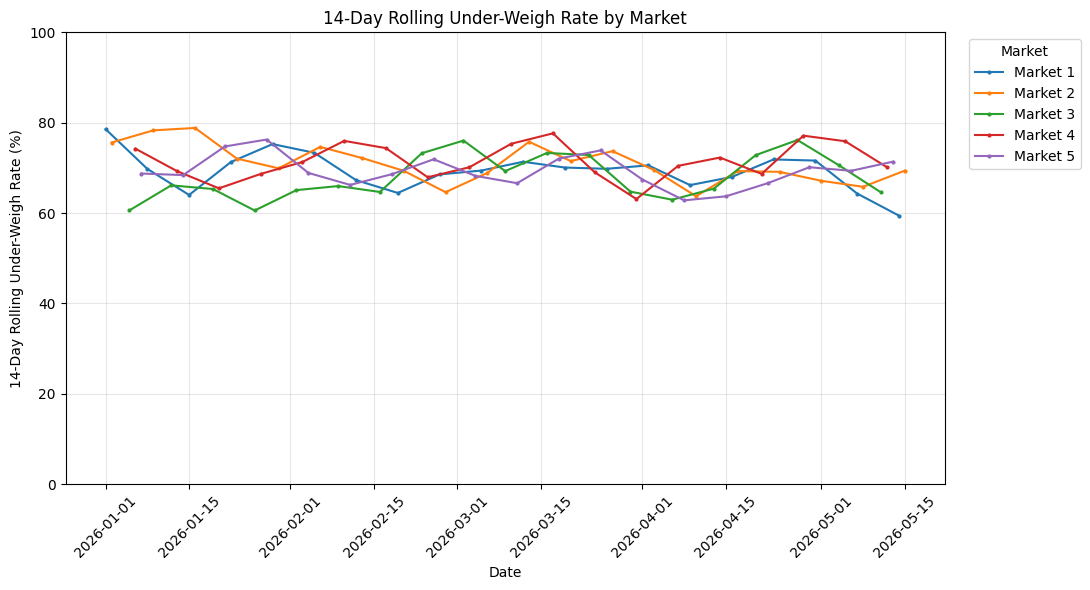


Median Expected Loss Table:
commodity    Bangus      Beef  Cabbage  Carrots   Chicken  Potatoes      Rice  \
market_id                                                                       
1          0.483330  1.164300  0.33303  0.23716  0.551580   0.30795  0.094950   
2          0.506055  1.191645  0.23354  0.27958  0.586410   0.28500  0.137235   
3          0.408700  0.795980  0.26130  0.27129  0.426140   0.27093  0.107200   
4          0.460405  1.066320  0.25082  0.30798  0.600705   0.24690  0.118160   
5          0.433180  1.101450  0.26676  0.30024  0.548850   0.25835  0.095540   

commodity  Tomatoes  
market_id            
1          0.189700  
2          0.183105  
3          0.225820  
4          0.228400  
5          0.196020  


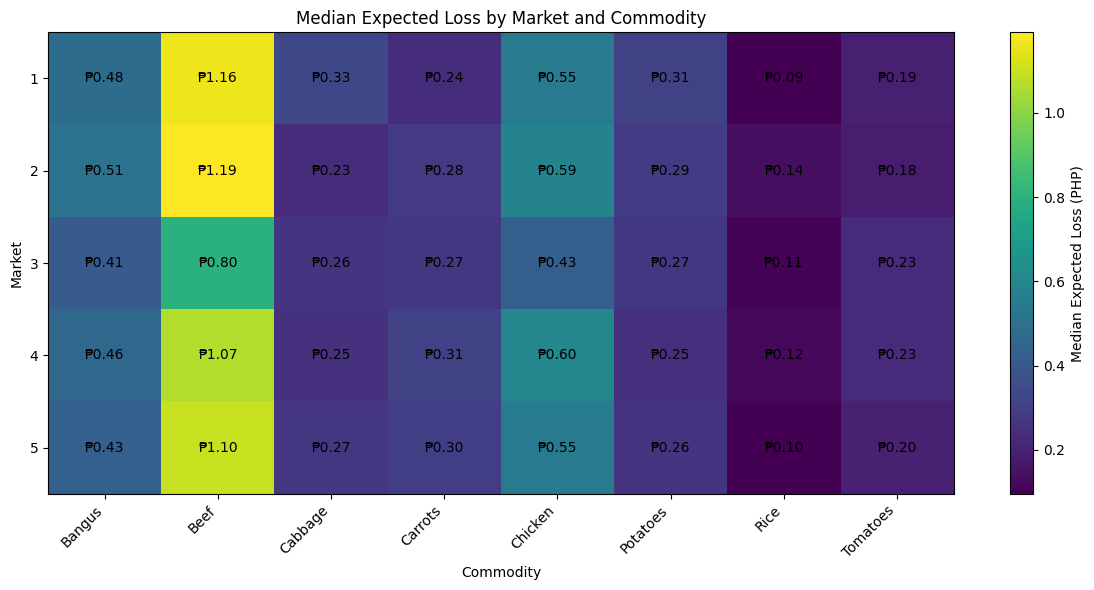


Calibration date:
2026-03-10 00:00:00

30 days before calibration:
(1776, 18)

30 days after calibration:
(1680, 18)


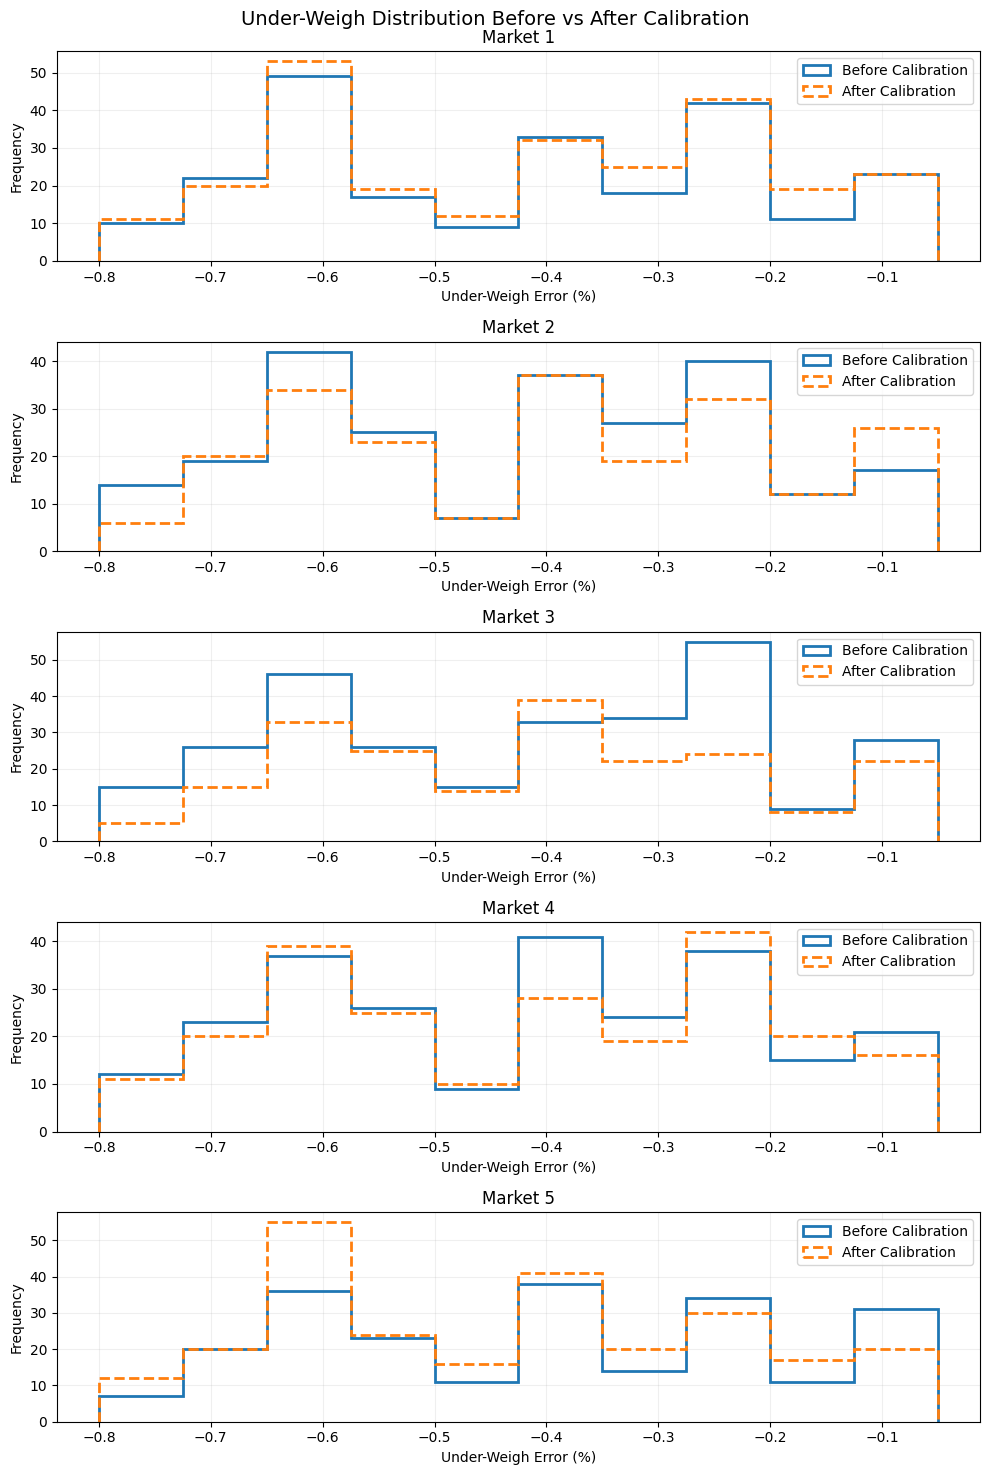

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

inspections = pd.read_csv("inspections.csv")
prices = pd.read_csv("prices.csv")
sales_samples = pd.read_csv("sales_samples.csv")

print("Inspections:", inspections.shape)
print("Prices:", prices.shape)
print("Sales samples:", sales_samples.shape)

inspections["date"] = pd.to_datetime(inspections["date"])
prices["date"] = pd.to_datetime(prices["date"])
sales_samples["date"] = pd.to_datetime(sales_samples["date"])

inspections.sort_values("date", inplace=True)
prices.sort_values("date", inplace=True)
sales_samples.sort_values("date", inplace=True)

inspections_sales_merge = pd.merge_asof(
    sales_samples,
    inspections,
    on="date",
    by=["stall_id", "market_id"],
    direction="nearest",
    tolerance=pd.Timedelta("7 days")
)

all_merge = pd.merge_asof(
    inspections_sales_merge,
    prices,
    on="date",
    by=["market_id", "commodity"],
    direction="backward",
    tolerance=pd.Timedelta("7 days")
)

all_merge["loss_php"] = (
    np.maximum(
        0,
        all_merge["label_weight_kg"]
        - all_merge["actual_weight_kg"]
    )
    * all_merge["avg_price_per_kg"]
)

all_merge["is_under_weigh"] = (
    all_merge["actual_weight_kg"]
    < all_merge["label_weight_kg"]
)

all_merge["error_weight_perc"] = (
    (
        all_merge["actual_weight_kg"]
        - all_merge["label_weight_kg"]
    )
    / all_merge["label_weight_kg"]
) * 100


# =========================================================
# FIGURE 1: 14-Day Rolling Under-Weigh Rate by Market
# =========================================================

# Calculate daily under-weigh rate per market first
daily_under_rate = (
    all_merge
    .groupby(["market_id", "date"])["is_under_weigh"]
    .mean()
    .reset_index()
)

# Calculate the 14-day rolling under-weigh rate
market_rolling_rate = (
    daily_under_rate
    .set_index("date")
    .groupby("market_id")["is_under_weigh"]
    .rolling("14D")
    .mean()
)

markets = sorted(all_merge["market_id"].unique())

plt.figure(figsize=(11, 6))

for market in markets:

    market_data = market_rolling_rate[market]

    plt.plot(
        market_data.index,
        market_data.values * 100,
        marker="o",
        markersize=2,
        linewidth=1.5,
        label="Market " + str(market)
    )

plt.xlabel("Date")
plt.ylabel("14-Day Rolling Under-Weigh Rate (%)")
plt.title("14-Day Rolling Under-Weigh Rate by Market")

plt.grid(True, alpha=0.3)

plt.legend(
    title="Market",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# =========================================================
# FIGURE 2: Median Expected Loss Heatmap
# =========================================================

loss_table = (
    all_merge
    .groupby(["market_id", "commodity"])["loss_php"]
    .median()
    .unstack()
)

print("\nMedian Expected Loss Table:")
print(loss_table)

loss_values = loss_table.to_numpy()

plt.figure(figsize=(12, 6))

plt.imshow(
    loss_values,
    aspect="auto"
)

plt.colorbar(
    label="Median Expected Loss (PHP)"
)

plt.xticks(
    np.arange(len(loss_table.columns)),
    loss_table.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(loss_table.index)),
    loss_table.index
)

# Add PHP values inside each heatmap cell
for i in range(loss_values.shape[0]):
    for j in range(loss_values.shape[1]):

        if not np.isnan(loss_values[i, j]):
            plt.text(
                j,
                i,
                f"₱{loss_values[i, j]:.2f}",
                ha="center",
                va="center"
            )

plt.xlabel("Commodity")
plt.ylabel("Market")
plt.title("Median Expected Loss by Market and Commodity")

plt.tight_layout()
plt.show()


# =========================================================
# FIGURE 3: Before vs After Calibration by Market
# =========================================================

# Use the actual calibration date from inspections.csv
all_merge["calibration_date"] = pd.to_datetime(
    all_merge["calibration_date"]
)

calibration_date = all_merge["calibration_date"].iloc[0]

print("\nCalibration date:")
print(calibration_date)

before_data = all_merge[
    (all_merge["date"] >= calibration_date - pd.Timedelta(days=30))
    & (all_merge["date"] < calibration_date)
]

after_data = all_merge[
    (all_merge["date"] > calibration_date)
    & (all_merge["date"] <= calibration_date + pd.Timedelta(days=30))
]

print("\n30 days before calibration:")
print(before_data.shape)

print("\n30 days after calibration:")
print(after_data.shape)


# Create 5 histograms, one for each market
fig, axes = plt.subplots(
    len(markets),
    1,
    figsize=(10, 15)
)

for i, market in enumerate(markets):

    before_market = before_data[
        (before_data["market_id"] == market)
        & (before_data["is_under_weigh"])
    ]["error_weight_perc"]

    after_market = after_data[
        (after_data["market_id"] == market)
        & (after_data["is_under_weigh"])
    ]["error_weight_perc"]

    # Before calibration
    axes[i].hist(
        before_market,
        bins=10,
        histtype="step",
        linewidth=2,
        label="Before Calibration"
    )

    # After calibration
    axes[i].hist(
        after_market,
        bins=10,
        histtype="step",
        linewidth=2,
        linestyle="--",
        label="After Calibration"
    )

    axes[i].set_title(
        "Market " + str(market)
    )

    axes[i].set_xlabel(
        "Under-Weigh Error (%)"
    )

    axes[i].set_ylabel(
        "Frequency"
    )

    axes[i].legend()

    axes[i].grid(
        True,
        alpha=0.2
    )


fig.suptitle(
    "Under-Weigh Distribution Before vs After Calibration",
    fontsize=14
)

plt.tight_layout()
plt.show()

# Task assignment

Member 1: Josef Jayden Nepomuceno - Dataset Generation: Created & generated inspections.csv & prices.csv

Member 2: Eivrard Seraphim Franco - Dataset Generation: Created & generated sales_samples.csv

Member 3: Ralph Aron Bonifacio - Performed Part A — NumPy: Measurement Error & Risk Flags

Member 4: Zachary Matthew Medallon - Performed Part B — pandas: Linking Errors to Consumer Impact

Member 5: Andrei Karl Dela Cruz -  Performed Part C — Matplotlib: Decision-Maker Visuals

Github link:
https://github.com/ralpharonbonifacio-glitch/Fair-Weigh-Fair-Pay-Data-Auditing-for-Public-Markets-GRP6-?fbclid=IwY2xjawUZ3OBwZG9mBWV4dG4DYWVtAjEwAGJyaWQRMWxDU3NpU3pHdGJFUWxhdmZzcnRjBmFwcF9pZBAyMjIwMzkxNzg4MjAwODkyAAEePFvIx0BY-gzdI8MnfBTUF_7S0YPtEre7CFhonmYB-aDBT2URPKO-TNe5SjQ_aem_csHlX5V9NRHu8pIvEoJ77g